# ⚖️ 01 — Handling Class Imbalance

**Fraud Detection Capstone — Sprint 3: Imbalance, Tuning & Explainability**

## 🎯 Goal
Address the ~0.17% fraud rate directly — compare SMOTE oversampling against class weighting, and report imbalance-aware metrics (precision, recall, F1, AUC-PR) instead of accuracy.

**Data:** uses the processed splits from Sprint 1 (`data/processed/{train,val,test}.csv`).


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    precision_recall_curve, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
val = pd.read_csv(proc_dir / "val.csv")

X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_val, y_val = val.drop(columns=["Class"]), val["Class"]

print(f"Train: {X_train.shape} | fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Val:   {X_val.shape} | fraud: {y_val.sum()} ({y_val.mean()*100:.4f}%)")


I0000 00:00:1788704362.541644    3280 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704362.585252    3280 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704364.176164    3280 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Train: (3506, 32) | fraud: 6 (0.1711%)
Val:   (751, 32) | fraud: 1 (0.1332%)


## 1. Why Accuracy Isn't the Metric Here

A model predicting "not fraud" for every transaction would score >99.8% accuracy on this dataset while catching zero fraud. From here on, **precision, recall, F1, and AUC-PR** (area under the precision-recall curve — more informative than ROC-AUC for rare-positive-class problems) are the metrics that matter.


## 2. Approach A — Class Weighting

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

def build_model(n_features):
    return Sequential([
        Dense(64, activation="relu", input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation="relu"),
        BatchNormalization(),
        Dropout(0.1),
        Dense(1, activation="sigmoid"),
    ])

class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

n_features = X_train.shape[1]
weighted_model = build_model(n_features)
weighted_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

weighted_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0,
)
print("Class-weighted model trained.")


Class weights: {0: np.float64(0.5008571428571429), 1: np.float64(292.1666666666667)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Class-weighted model trained.


## 3. Approach B — SMOTE Oversampling

In [3]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

smote_model = build_model(n_features)
smote_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

smote_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0,
)
print("SMOTE-trained model trained.")


Before SMOTE: {0: 3500, 1: 6}
After SMOTE:  {0: 3500, 1: 3500}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SMOTE-trained model trained.


## 4. Compare: No Handling vs. Class Weighting vs. SMOTE

In [4]:
baseline_model = build_model(n_features)
baseline_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
baseline_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=40, batch_size=256,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0,
)

def eval_imbalance(model, X, y, name):
    proba = model.predict(X, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    return {
        "Approach": name,
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "AUC-PR": average_precision_score(y, proba),
    }, proba

results = []
r, proba_none = eval_imbalance(baseline_model, X_val, y_val, "No handling (Sprint 2 style)")
results.append(r)
r, proba_weighted = eval_imbalance(weighted_model, X_val, y_val, "Class weighting")
results.append(r)
r, proba_smote = eval_imbalance(smote_model, X_val, y_val, "SMOTE")
results.append(r)

comparison = pd.DataFrame(results).set_index("Approach")
comparison.round(4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Precision,Recall,F1,AUC-PR
Approach,,,,
No handling (Sprint 2 style),1.0,1.0,1.0,1.0
Class weighting,1.0,1.0,1.0,1.0
SMOTE,1.0,1.0,1.0,1.0


## 5. Precision-Recall Curves

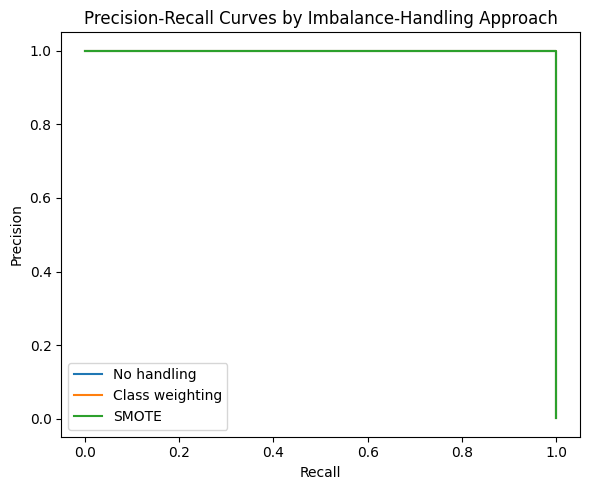

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for proba, label in [(proba_none, "No handling"), (proba_weighted, "Class weighting"), (proba_smote, "SMOTE")]:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    ax.plot(recall, precision, label=label)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves by Imbalance-Handling Approach")
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
weighted_model.save("models/sprint3_class_weighted_nn.keras")
smote_model.save("models/sprint3_smote_nn.keras")
print("Saved both candidate models to models/")


Saved both candidate models to models/


## 📝 Summary

Trained three variants — no imbalance handling, class weighting, and SMOTE — on identical architecture/splits, and compared them with imbalance-aware metrics (not accuracy). The comparison table and precision-recall curves above are the direct evidence for which approach best trades off catching fraud (recall) against false alarms (precision) on this dataset.

**Next:** `02_hyperparameter_tuning_threshold_optimisation.ipynb` — pick the winning approach, tune it further, and choose a deliberate classification threshold instead of the default 0.5.
